# MPoint3d (Multi-Point 3D) Demonstration Notebook

## Overview

This notebook demonstrates the functionality of the `MPoint3d` class from the `upxo.geoEntities.mulpoint3d` module, a powerful tool for working with 3D point cloud data. The `MPoint3d` class provides methods for creating, manipulating, transforming, and visualizing collections of 3D points.

## Key Features Demonstrated

### 1. **Point Cloud Creation**
- Creating point clouds from random coordinates
- Constructing point clouds from explicit coordinate arrays
- Generating structured 3D grids using xyz specifications

### 2. **Geometric Transformations**
- Translation operations with customizable reference points
- Rotation transformations (supporting degree and radian modes)
- Combined translation and rotation operations
- Centroid-based transformations

### 3. **Spatial Analysis**
- Building KD-Tree data structures for efficient spatial queries
- Finding first-order neighbors in cubic voxel grids
- Voxel-based spatial partitioning (voxel size: 0.1 units)

### 4. **Visualization**
- 3D plotting capabilities with customizable marker sizes
- Overlay plotting for comparing original and transformed point sets

## Notebook Structure

The notebook is organized into progressive examples:
- Basic point cloud creation and inspection
- Coordinate access and manipulation
- Geometric transformations without rotation
- Rotation transformations (45° and multi-axis rotations)
- Grid-based point cloud generation with complex transformations
- Spatial indexing with scipy's cKDTree
- Voxel-based neighbor finding

## Dependencies

- `upxo.geoEntities.mulpoint3d` - Core MPoint3d functionality
- `numpy` - Numerical operations and array handling
- `matplotlib.pyplot` - 3D visualization
- `scipy.spatial.cKDTree` - Spatial indexing and nearest neighbor queries

## Use Cases

This notebook is useful for:
- Geospatial data analysis
- 3D point cloud processing
- Computational geometry applications
- Spatial data structure experimentation
- Geometric transformation workflows

In [1]:
from upxo.geoEntities.mulpoint3d import MPoint3d as mp3d
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mulpoint3d = mp3d.from_coords(np.random.random((10,3)))
print(mulpoint3d)
print(mulpoint3d[9])
print(mulpoint3d.coords)

UPXO-mp3d. n=10.
[0.64388368 0.47797808 0.37133448]
[[0.77604743 0.79417054 0.23333772]
 [0.48585611 0.07127426 0.61447869]
 [0.22494741 0.32246567 0.49530374]
 [0.30799043 0.84356402 0.99539019]
 [0.03149146 0.6072229  0.6264384 ]
 [0.68467034 0.47427396 0.27397233]
 [0.74652777 0.85062823 0.3188541 ]
 [0.87195215 0.55716048 0.46434983]
 [0.06650046 0.66402841 0.48175887]
 [0.64388368 0.47797808 0.37133448]]


In [3]:
point_coords = np.array([[0, 0, 0], [1, 1, 1], [2, 3, 3], [4, 5, 6]])
MULPOINT3D = mp3d.from_coords(point_coords)
MULPOINT3D.coords

array([[0, 0, 0],
       [1, 1, 1],
       [2, 3, 3],
       [4, 5, 6]])

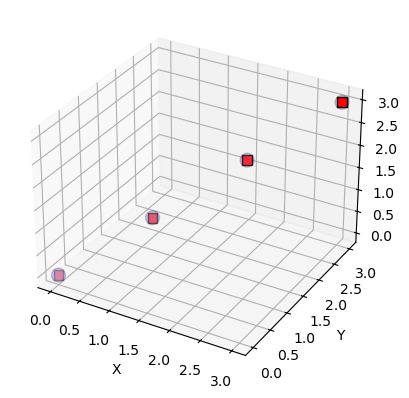

In [4]:
point_coords = np.array([[0, 0, 0], [1, 1, 1], [2, 2, 2], [3, 3, 3]])
mulpoint3d = mp3d.from_coords(point_coords)
MULPOINT3D = mp3d.from_mulpoint3d(mulpoint3d=mulpoint3d,
                                    dxyz=[0.0, 0.0, 0.0],
                                    translate_ref=mulpoint3d.centroid,
                                    rot=[0.0, 0.0, 0.0],
                                    rot_ref=[0.0, 0.0, 0.0],
                                    degree=True)
mulpoint3d.plot(MULPOINT3D.coords)

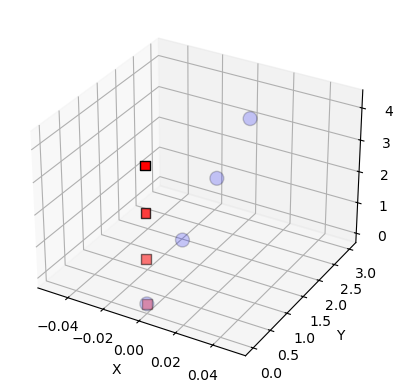

In [5]:
point_coords = np.array([[0, 0, 0], [0, 1, 1], [0, 2, 2], [0, 3, 3]])
mulpoint3d = mp3d.from_coords(point_coords)
MULPOINT3D = mp3d.from_mulpoint3d(mulpoint3d=mulpoint3d,
                                    dxyz=[0.0, 0.0, 0.0],
                                    translate_ref=mulpoint3d.centroid,
                                    rot=[45, 0.0, 0.0],
                                    rot_ref=[0.0, 0.0, 0.0],
                                    degree=True)
mulpoint3d.plot(MULPOINT3D.coords)

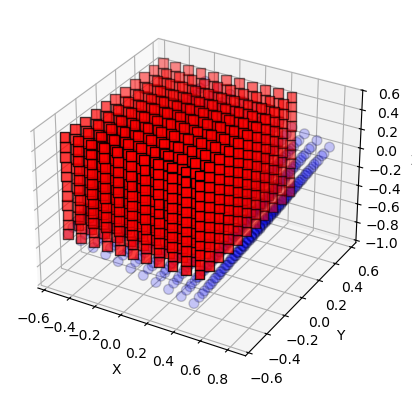

In [6]:
xspec, yspec, zspec = [0, 1, 0.1], [0, 1, 0.1], [0, 1, 0.1]
dxyz, translate_ref = [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]
mulpoint3d = mp3d.from_xyz_grid(xspec=xspec, yspec=yspec, zspec=zspec,
                                dxyz=dxyz, translate_ref=translate_ref,
                                rot=[0.0, 0.0, 0.0],
                                rot_ref=[0.0, 0.0, 0.0],
                                degree=True)
MULPOINT3D = mp3d.from_xyz_grid(xspec=xspec, yspec=yspec, zspec=zspec,
                                        dxyz=dxyz, translate_ref=translate_ref,
                                        rot=[5.0, 25.0, 5.0],
                                        rot_ref=[0.0, 0.0, 0.0],
                                        degree=True)
MULPOINT3D.plot(mulpoint3d.coords, primary_ms=50, secondary_ms=5)

In [7]:
mulpoint3d = mp3d.from_coords(np.random.random((25, 3)))
mulpoint3d.coords
from scipy.spatial import cKDTree as ckdt
a = ckdt(mulpoint3d.coords, copy_data=False, balanced_tree=True)
a.data

array([[0.72060787, 0.21496286, 0.75866375],
       [0.91477985, 0.38181496, 0.32919492],
       [0.14248787, 0.02840919, 0.38887985],
       [0.97378225, 0.52132852, 0.70952724],
       [0.68516196, 0.59225026, 0.36467939],
       [0.49215827, 0.54089622, 0.55787489],
       [0.68676053, 0.51408998, 0.12957713],
       [0.74159793, 0.89241855, 0.54843366],
       [0.5580999 , 0.59072369, 0.02954101],
       [0.77459057, 0.26028991, 0.54308597],
       [0.26850046, 0.2618841 , 0.24499263],
       [0.42324683, 0.98689669, 0.00847109],
       [0.91121781, 0.37093398, 0.80866739],
       [0.63622303, 0.51806711, 0.30278262],
       [0.87371002, 0.21907899, 0.01726276],
       [0.22949492, 0.43570639, 0.45855724],
       [0.46214848, 0.37843229, 0.06888582],
       [0.27864492, 0.05613207, 0.44829806],
       [0.6830759 , 0.0369998 , 0.16801132],
       [0.62684014, 0.75430346, 0.51860513],
       [0.95191591, 0.57435617, 0.10568613],
       [0.15689157, 0.85190249, 0.41578979],
       [0.

In [8]:
vs = 0.1  # Voxel size
xspec, yspec, zspec = [0, 1, vs], [0, 1, vs], [0, 1, vs]
X, Y, Z = np.meshgrid(np.arange(xspec[0], xspec[1], xspec[2]),
                        np.arange(yspec[0], yspec[1], yspec[2]),
                        np.arange(zspec[0], zspec[1], zspec[2]))
mp = mp3d.from_coords(np.vstack((X.ravel(), Y.ravel(), Z.ravel())).T)
mp.find_first_order_neigh_CUBIC((0.5, 0.5, 0.5), vs)

(array([[444, 445, 446, 454, 455, 456, 464, 465, 466, 544, 545, 546, 554,
         555, 556, 564, 565, 566, 644, 645, 646, 654, 655, 656, 664, 665,
         666]]),
 array([[[0.4, 0.4, 0.4],
         [0.4, 0.4, 0.5],
         [0.4, 0.4, 0.6],
         [0.5, 0.4, 0.4],
         [0.5, 0.4, 0.5],
         [0.5, 0.4, 0.6],
         [0.6, 0.4, 0.4],
         [0.6, 0.4, 0.5],
         [0.6, 0.4, 0.6],
         [0.4, 0.5, 0.4],
         [0.4, 0.5, 0.5],
         [0.4, 0.5, 0.6],
         [0.5, 0.5, 0.4],
         [0.5, 0.5, 0.5],
         [0.5, 0.5, 0.6],
         [0.6, 0.5, 0.4],
         [0.6, 0.5, 0.5],
         [0.6, 0.5, 0.6],
         [0.4, 0.6, 0.4],
         [0.4, 0.6, 0.5],
         [0.4, 0.6, 0.6],
         [0.5, 0.6, 0.4],
         [0.5, 0.6, 0.5],
         [0.5, 0.6, 0.6],
         [0.6, 0.6, 0.4],
         [0.6, 0.6, 0.5],
         [0.6, 0.6, 0.6]]]),
 array([0.5, 0.5, 0.5]))